# Quantifying uniform vs. non-uniform point patterns — Grid-binning, Nearest-neighbour & K-means

**Reference:** Kashyap, Kiran & Gupta, arXiv:2507.04890v2 (§S4 Voronoi analysis & §S2 vortex-center
statistics). Companion to notebook&nbsp;`01_voronoi_uniform_vs_nonuniform.ipynb`.

Notebook&nbsp;1 used **Voronoi cell area** to separate a homogeneous from a clustered set of
points. Here we test three *alternative* PDF-based diagnostics for the same uniform-vs-clustered
question — the methods we explored to quantify inhomogeneity:

| # | Method | PDF that is compared |
|---|--------|----------------------|
| 1 | **Square-grid binning** | PDF of normalised cell occupancy $\chi = k/\langle k\rangle$ (+ Fano-factor test) |
| 2 | **Nearest-neighbour distance** | PDF of distance to the closest neighbour (CV vs. Poisson reference) |
| 3 | **K-means clustering** | PDF of each point's distance to its assigned cluster centroid |

**Changes from the original script (all approved):**
- one **shared** uniform dataset and one **shared** non-uniform dataset feed *every* method, so the
  comparison is apples-to-apples (the original used different `n`/cluster counts per method);
- the hardcoded "degree of uniformity" constants (`/0.00835`, `/0.58`) are replaced by the
  **theoretical Poisson nearest-neighbour CV $= \sqrt{4/\pi-1}\approx0.5227$**;
- the decision print-outs now reference each dataset's own statistic (the original referenced a
  global variable and could mislabel);
- **K-means** clustering and its PDF are added (absent from the original file).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.cluster.vq import kmeans2

rng = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


## Shared datasets

`points_uni` — `n` points uniform over the unit square (Poisson / homogeneous reference).

`points_clu` — the same `n` points, packed into 4 Gaussian clusters of uneven population and
spread, plus a uniform background of noise points (the inhomogeneous case). Both methods below
read **these same two arrays**.


uniform: (1000, 2)  clustered: (1000, 2)


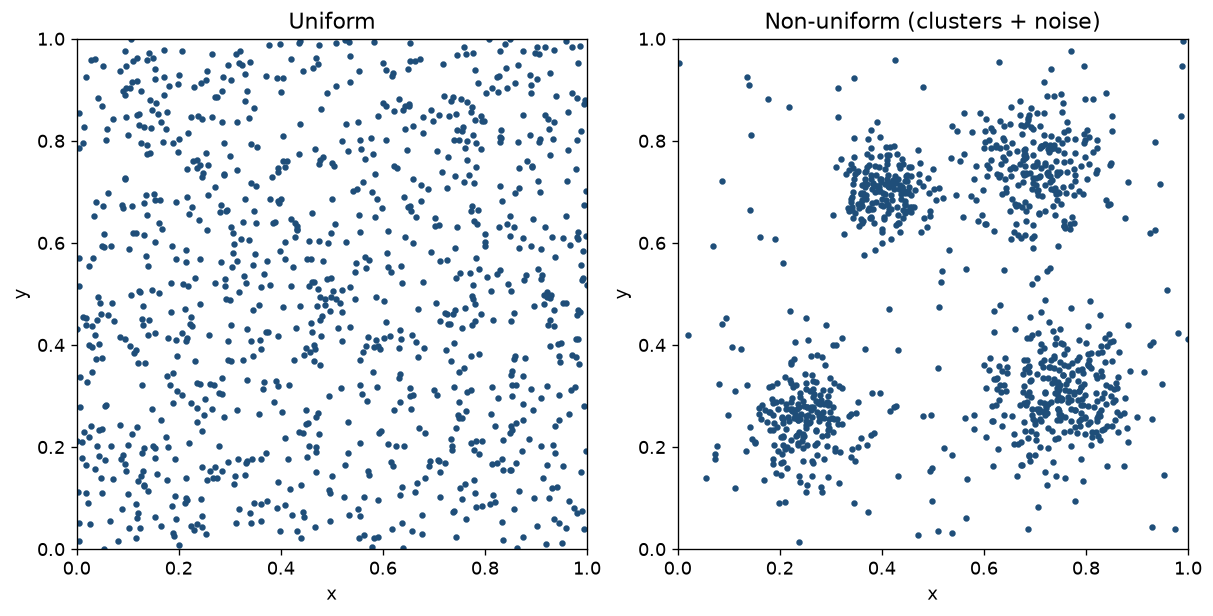

In [2]:
n = 1000
L = 1.0

def make_uniform(n, rng):
    return rng.uniform(0, L, size=(n, 2))

def make_clustered(n, rng, centers=((0.25,0.25),(0.75,0.30),(0.40,0.70),(0.70,0.75)),
                   noise=120):
    centers = np.asarray(centers)
    remaining, blobs = n - noise, []
    for i, c in enumerate(centers):
        m = remaining if i == len(centers)-1 else int(rng.integers(150, 300))
        remaining -= 0 if i == len(centers)-1 else m
        spread = rng.uniform(0.04, 0.08)
        blobs.append(rng.normal(c, spread, size=(m, 2)))
    blobs.append(rng.uniform(0, L, size=(noise, 2)))          # background
    return np.clip(np.vstack(blobs), 1e-6, L-1e-6)

points_uni = make_uniform(n, rng)
points_clu = make_clustered(n, rng)
print("uniform:", points_uni.shape, " clustered:", points_clu.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
for a, p, t in zip(ax, (points_uni, points_clu), ("Uniform", "Non-uniform (clusters + noise)")):
    a.scatter(p[:,0], p[:,1], s=8, color="#1f4e79")
    a.set(title=t, xlim=(0,L), ylim=(0,L), xlabel="x", ylabel="y"); a.set_aspect("equal")
plt.show()


## Method 1 — Square-grid binning

Lay a `num_bins x num_bins` grid over the box and count points per cell, $k$. For a homogeneous
(Poisson) field the counts are Poisson-distributed, so the **Fano factor** $F=\mathrm{Var}(k)/\langle k\rangle$
is $\approx 1$; clustering inflates the variance and pushes $F>1$. The $2\sigma$ band around 1 is
$1\pm2\sqrt{2/M}$ with $M=$ number of cells. We also plot the **PDF of normalised occupancy**
$\chi=k/\langle k\rangle$: narrow and peaked at 1 for uniform, broad (many empty cells + a few
crowded ones) for clustered.


In [3]:
num_bins = 20
M = num_bins**2

def occupancy(points):
    H, _, _ = np.histogram2d(points[:,0], points[:,1], bins=num_bins, range=[[0,L],[0,L]])
    k = H.flatten()
    return k, k.var()/k.mean()                                   # counts, Fano factor

k_uni, fano_uni = occupancy(points_uni)
k_clu, fano_clu = occupancy(points_clu)

lower, upper = 1 - 2*np.sqrt(2/M), 1 + 2*np.sqrt(2/M)
for label, fano in (("Uniform", fano_uni), ("Non-uniform", fano_clu)):
    verdict = ("clustered" if fano > upper else
               "too regular/ordered" if fano < lower else
               "consistent with uniform random")
    print(f"{label:12s} Fano = {fano:6.3f}   (CSR band [{lower:.3f}, {upper:.3f}])  -> {verdict}")


Uniform      Fano =  0.946   (CSR band [0.859, 1.141])  -> consistent with uniform random
Non-uniform  Fano =  8.902   (CSR band [0.859, 1.141])  -> clustered


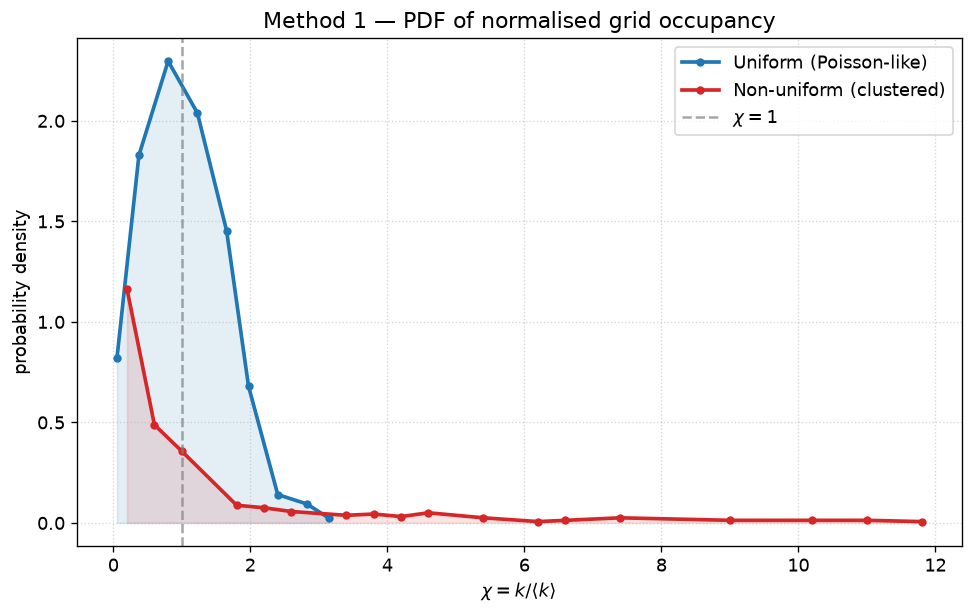

In [4]:
def occ_pdf(k, ax, label, color):
    chi = k / k.mean()
    dens, edges = np.histogram(chi, bins=30, density=True)
    ctr = 0.5*(edges[:-1] + edges[1:])
    m = dens > 0                                                 # drop empty bins (no spikes to axis)
    ax.plot(ctr[m], dens[m], lw=2.2, marker="o", ms=4, color=color, label=label)
    ax.fill_between(ctr[m], dens[m], alpha=0.12, color=color)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
occ_pdf(k_uni, ax, "Uniform (Poisson-like)", "#1f77b4")
occ_pdf(k_clu, ax, "Non-uniform (clustered)", "#d62728")
ax.axvline(1, color="gray", ls="--", alpha=0.7, label=r"$\chi=1$")
ax.set(title="Method 1 — PDF of normalised grid occupancy",
       xlabel=r"$\chi = k/\langle k\rangle$", ylabel="probability density")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.show()


## Method 2 — Nearest-neighbour distance

For each point, the distance to its closest neighbour (via a KD-tree). The shape of this PDF and,
in particular, its **coefficient of variation** $\mathrm{CV}=\sigma/\mu$ separate the two cases.
For a 2-D Poisson process the NN distance follows a Rayleigh law with a fixed
$\mathrm{CV}_\mathrm{Poisson}=\sqrt{4/\pi-1}\approx0.5227$ — this is the principled reference that
replaces the original script's hardcoded constants. Clustering produces many very small NN
distances plus a tail, so $\mathrm{CV}>\mathrm{CV}_\mathrm{Poisson}$.


In [5]:
CV_POISSON = np.sqrt(4/np.pi - 1)        # ~0.5227, 2D Poisson nearest-neighbour reference

def nn_distances(points):
    d, _ = cKDTree(points).query(points, k=2)   # k=2: self + nearest
    return d[:, 1]

nn_uni, nn_clu = nn_distances(points_uni), nn_distances(points_clu)

for label, d in (("Uniform", nn_uni), ("Non-uniform", nn_clu)):
    cv = d.std()/d.mean()
    ratio = cv / CV_POISSON
    verdict = "non-uniform (clustered)" if ratio > 1 else "consistent with uniform"
    print(f"{label:12s} mean={d.mean():.4f}  std={d.std():.4f}  CV={cv:.4f}  "
          f"CV/CV_Poisson={ratio:.2f}  -> {verdict}")


Uniform      mean=0.0166  std=0.0086  CV=0.5179  CV/CV_Poisson=0.99  -> consistent with uniform
Non-uniform  mean=0.0121  std=0.0135  CV=1.1110  CV/CV_Poisson=2.13  -> non-uniform (clustered)


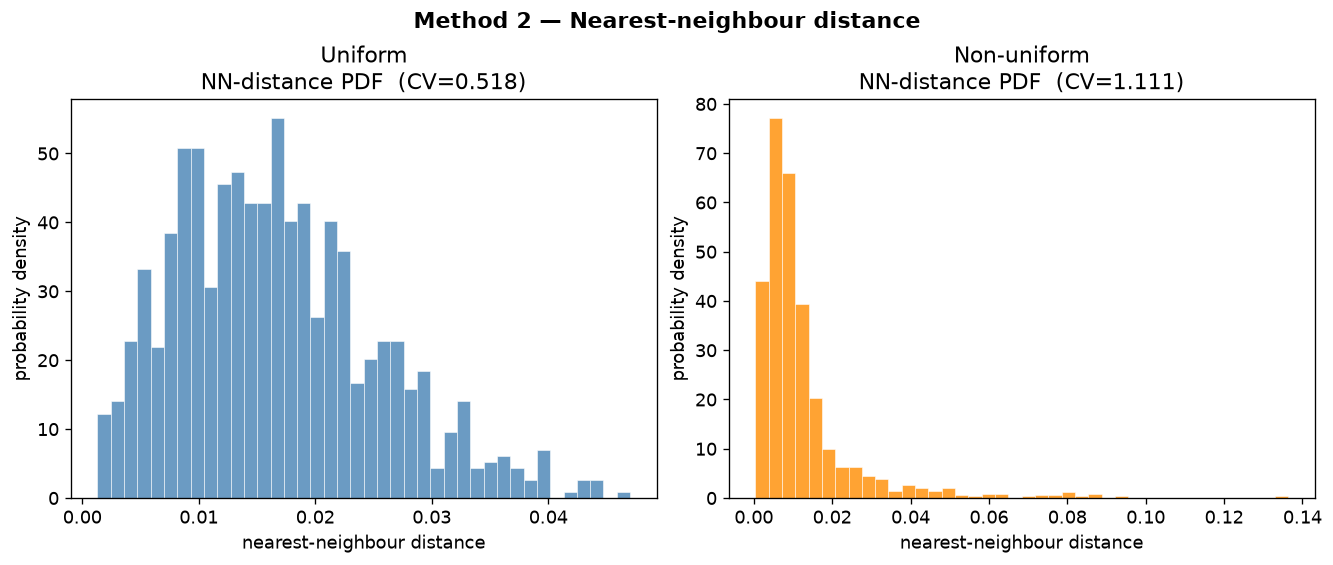

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
for a, d, t, c in zip(ax, (nn_uni, nn_clu), ("Uniform", "Non-uniform"),
                      ("steelblue", "darkorange")):
    a.hist(d, bins=40, density=True, color=c, alpha=0.8, edgecolor="white", linewidth=0.4)
    a.set(title=f"{t}\nNN-distance PDF  (CV={d.std()/d.mean():.3f})",
          xlabel="nearest-neighbour distance", ylabel="probability density")
fig.suptitle("Method 2 — Nearest-neighbour distance", fontweight="bold")
plt.show()


## Method 3 — K-means clustering  *(added)*

Partition each point set into `k` clusters with K-means (`scipy.cluster.vq.kmeans2`, k-means++
seeding) and record every point's **distance to its assigned centroid**. This is the K-means
analog of the Voronoi-area diagnostic:

- **Uniform** — centroids spread out to tile the box, so point-to-centroid distances are
  comparatively large and broadly spread (no tight grouping exists to find).
- **Clustered** — K-means locks onto the dense blobs, so most distances collapse toward **zero**
  (tight clusters) with a tail from the background noise.

`k` is the one free parameter; we set it to the number of planted clusters (4) and note the
result is qualitatively robust to the choice.


In [7]:
k = 4

def centroid_distances(points, k, seed=0):
    centroids, labels = kmeans2(points.astype(float), k, minit="++", seed=seed)
    d = np.linalg.norm(points - centroids[labels], axis=1)
    return centroids, labels, d

cen_uni, lab_uni, dc_uni = centroid_distances(points_uni, k)
cen_clu, lab_clu, dc_clu = centroid_distances(points_clu, k)

for label, d in (("Uniform", dc_uni), ("Non-uniform", dc_clu)):
    print(f"{label:12s} mean dist-to-centroid={d.mean():.4f}  std={d.std():.4f}  "
          f"CV={d.std()/d.mean():.3f}")


Uniform      mean dist-to-centroid=0.2185  std=0.1056  CV=0.483
Non-uniform  mean dist-to-centroid=0.0936  std=0.0641  CV=0.684


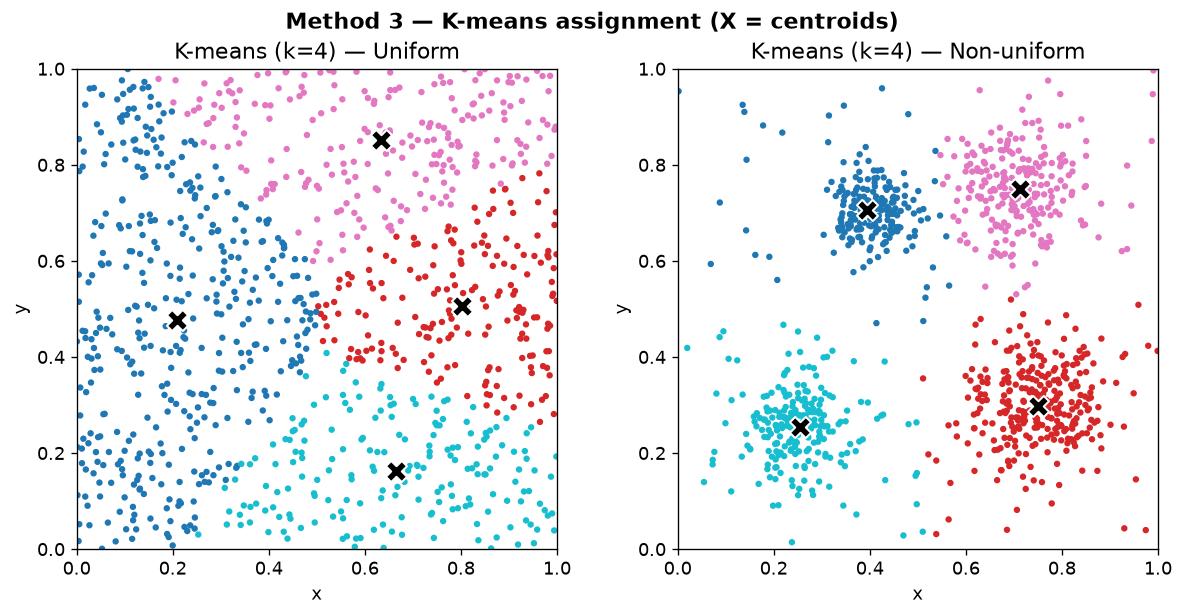

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
for a, p, lab, cen, t in zip(ax, (points_uni, points_clu), (lab_uni, lab_clu),
                             (cen_uni, cen_clu), ("Uniform", "Non-uniform")):
    a.scatter(p[:,0], p[:,1], s=8, c=lab, cmap="tab10")
    a.scatter(cen[:,0], cen[:,1], s=160, c="k", marker="X", edgecolor="white", linewidth=1.2)
    a.set(title=f"K-means (k={k}) — {t}", xlim=(0,L), ylim=(0,L), xlabel="x", ylabel="y")
    a.set_aspect("equal")
fig.suptitle("Method 3 — K-means assignment (X = centroids)", fontweight="bold")
plt.show()


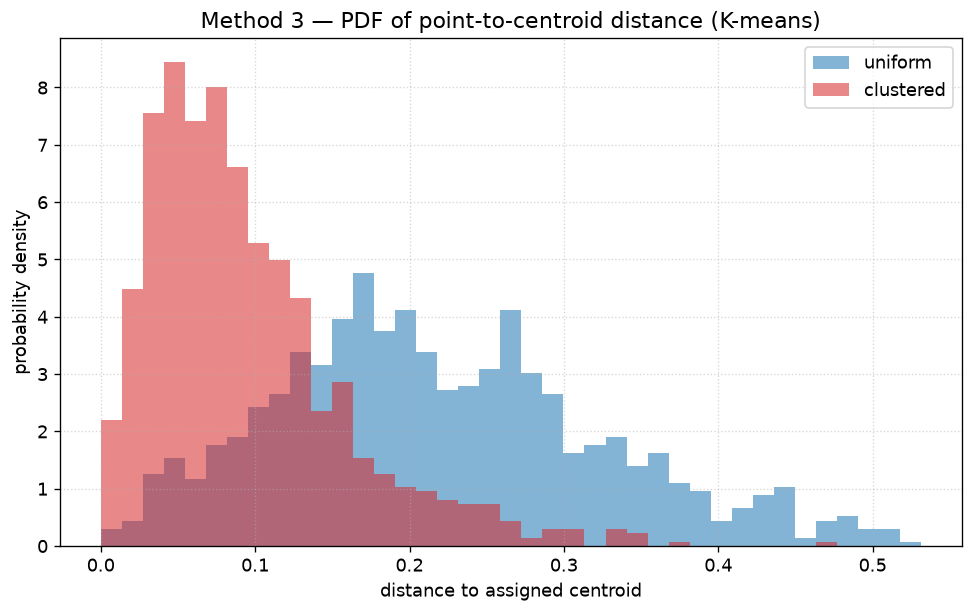

In [9]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
bins = np.linspace(0, max(dc_uni.max(), dc_clu.max()), 40)
ax.hist(dc_uni, bins=bins, density=True, alpha=0.55, color="#1f77b4", label="uniform")
ax.hist(dc_clu, bins=bins, density=True, alpha=0.55, color="#d62728", label="clustered")
ax.set(title="Method 3 — PDF of point-to-centroid distance (K-means)",
       xlabel="distance to assigned centroid", ylabel="probability density")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.show()


## Summary

| diagnostic | uniform | clustered | separates the cases? |
|---|---|---|---|
| Grid Fano factor $F$ | $\approx1$ | $\gg1$ | yes — variance of occupancy |
| Occupancy PDF $\chi$ | narrow, peak at 1 | broad, many empty + crowded cells | yes |
| NN-distance CV | $\approx0.52$ (Poisson) | $>0.52$ | yes — small-distance spike + tail |
| K-means centroid-distance PDF | broad, peaked away from 0 | spike near 0 + tail | yes |

All three PDF-based methods agree with the Voronoi analysis of notebook 1: a homogeneous point
set yields a narrow, single-scale distribution, while clustering **broadens** the relevant PDF and
grows a heavy tail. The K-means centroid-distance PDF is the closest in spirit to the Voronoi-area
PDF — both measure a *local length/area scale* and both broaden under clustering. The natural next
step is to drive all of these with **real vortex-center coordinates** (Okubo–Weiss extraction, §S2)
instead of synthetic points.
